In [12]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings("ignore")

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


In [21]:
df1 = pd.read_csv("../data/kaggle/kaggle_steam_reviews.csv")
df2 = pd.read_csv("../data/kaggle/kaggle_steam_game.csv")

df2_filtered = df2[df2['reviews'].notnull()]

print(df1.head(3))
print(df2.head(3))
print(f" {df1['app_id'].nunique()} jogos únicos no df1")
print(f" {df2['appid'].nunique()} jogos únicos no df2")
# print(f" {df2_filtered['reviews'].count() + df1['reviews'].count()} jogos únicos com reviews no df2 filtrado + df1")

   app_id        app_name                                        review_text  \
0      10  Counter-Strike                                    Ruined my life.   
1      10  Counter-Strike  This will be more of a ''my experience with th...   
2      10  Counter-Strike                      This game saved my virginity.   

   review_score  review_votes  
0             1             0  
1             1             1  
2             1             0  
    appid                 name release_date  required_age  price  dlc_count  \
0     730     Counter-Strike 2   2012-08-21             0    0.0          1   
1  578080  PUBG: BATTLEGROUNDS   2017-12-21             0    0.0          0   
2     570               Dota 2   2013-07-09             0    0.0          2   

                                detailed_description  \
0  For over two decades, Counter-Strike has offer...   
1  LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...   
2  The most-played game on Steam. Every day, mill...   

         

In [2]:
processed_file = "../data/processed/games_metadata_with_embeddings.json"

if not os.path.exists(processed_file):
    print("⚠️ Execute o pipeline de extração semântica primeiro.")
else:
    with open(processed_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    df = pd.json_normalize(data)
    # Garante que a coluna base_price seja float para satisfazer o Seaborn/Pylance
    df['base_price'] = df['base_price'].astype(float)
    
    print(f"Base carregada com sucesso! Total de jogos consolidados: {len(df)}")
    display(df.head(3))

✅ Base carregada com sucesso! Total de jogos consolidados: 200


,game_id,game_name,base_price,release_date,primary_genre,semantic_profile
0,20,Team Fortress Classic,4.99,1999-04-01,FPS,"[{'feature_name': 'Gameplay', 'weight': 0.8}, ..."
1,240,Counter-Strike: Source,9.99,2004-11-01,FPS,"[{'feature_name': 'fun_factor', 'weight': 0.8}..."
2,300,Day of Defeat: Source,9.99,2010-07-12,FPS,"[{'feature_name': 'Multiplayer', 'weight': 0.8..."


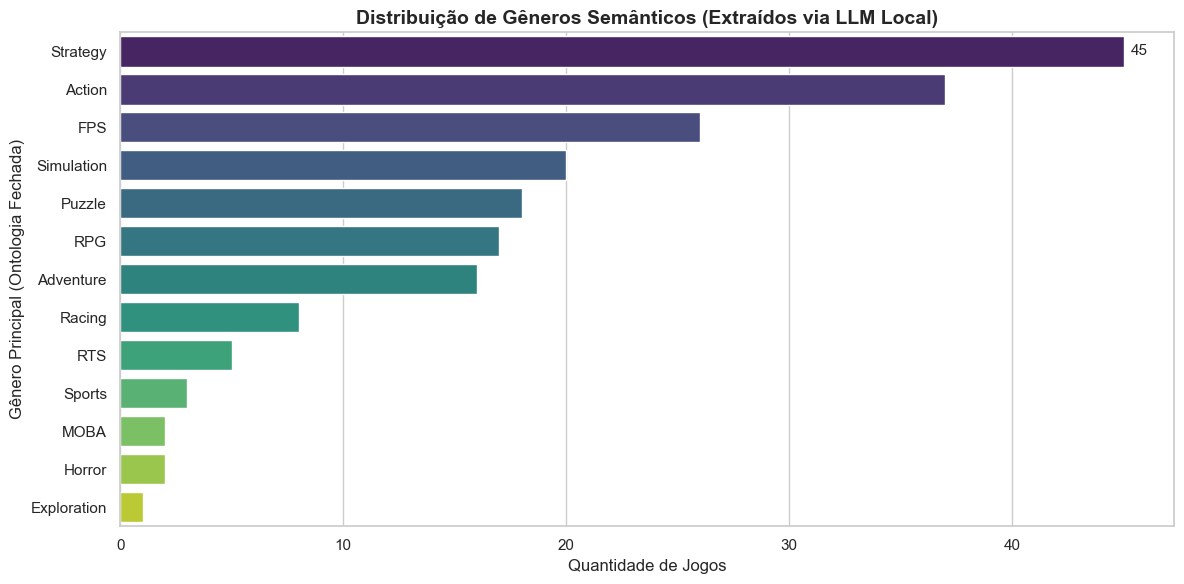

In [3]:
plt.figure(figsize=(12, 6))

# Usando y='primary_genre' e data=df resolve os avisos de tipagem do Pylance
ax = sns.countplot(data=df, hue='primary_genre', order=df['primary_genre'].value_counts().index, palette="viridis", legend=False)
plt.title("Distribuição de Gêneros Semânticos (Extraídos via LLM Local)", fontsize=14, fontweight='bold')
plt.xlabel("Quantidade de Jogos", fontsize=12)
plt.ylabel("Gênero Principal (Ontologia Fechada)", fontsize=12)

# Uso moderno de bar_label (Sem loops complexos de Patch)
ax.bar_label(ax.containers[0], padding=5, fontsize=11)

plt.tight_layout()
plt.show()

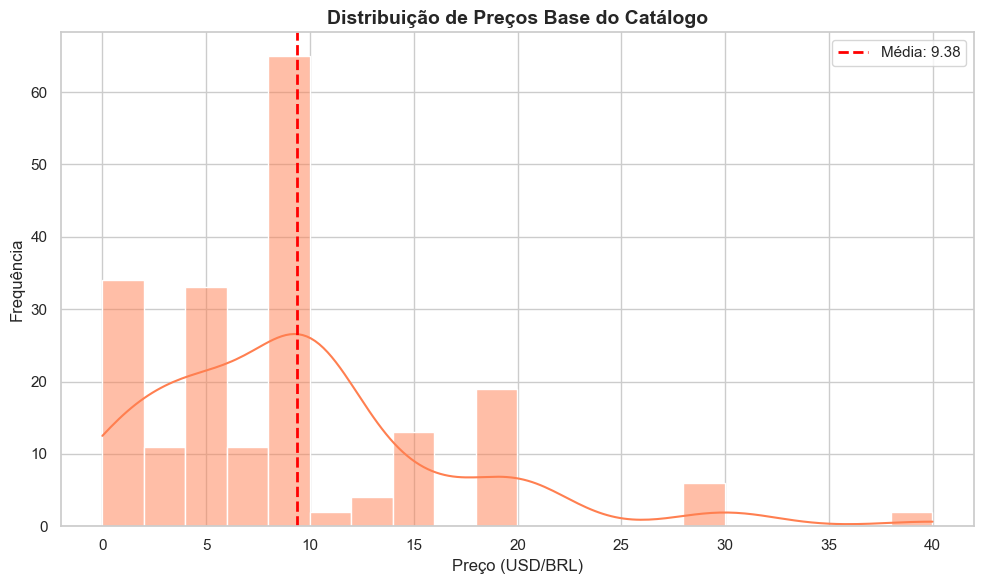

In [4]:
plt.figure(figsize=(10, 6))

# Agora passamos data=df e x='base_price'. O Pylance entende isso perfeitamente.
sns.histplot(data=df, x='base_price', bins=20, kde=True, color="coral", legend=False)
plt.title("Distribuição de Preços Base do Catálogo", fontsize=14, fontweight='bold')
plt.xlabel("Preço (USD)", fontsize=12)
plt.ylabel("Frequência", fontsize=12)

mean_price = df['base_price'].mean()
plt.axvline(mean_price, color='red', linestyle='dashed', linewidth=2, label=f'Média: {mean_price:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

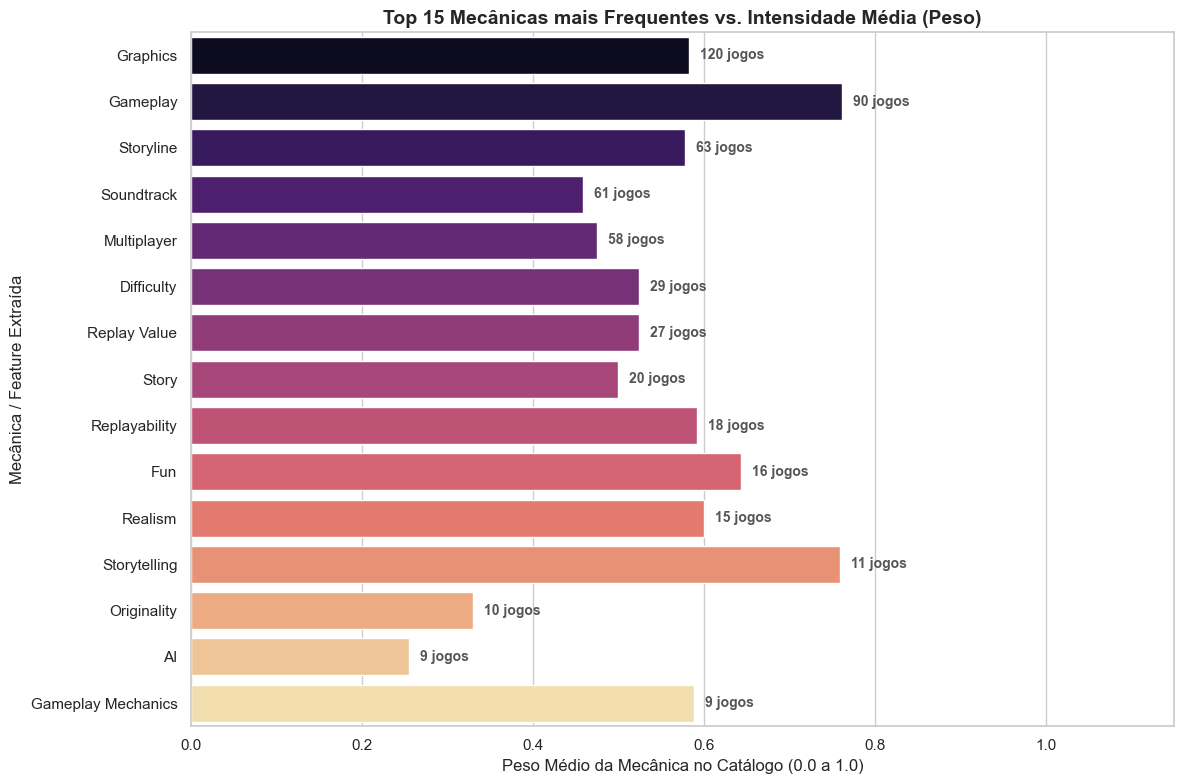

In [14]:
features_data = []
for _, row in df.iterrows():
    if isinstance(row['semantic_profile'], list):
        for feature in row['semantic_profile']:
            features_data.append({
                'game_name': row['game_name'],
                'feature_name': feature['feature_name'],
                'weight': float(feature['weight'])
            })

df_features = pd.DataFrame(features_data)

# Pega as 15 mecânicas mais citadas em todo o catálogo
top_15_features = df_features['feature_name'].value_counts().head(15)
df_top = df_features[df_features['feature_name'].isin(top_15_features.index)]

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=df_top, 
    y='feature_name', 
    x='weight', 
    estimator=np.mean, 
    errorbar=None, 
    order=top_15_features.index, 
    palette="magma"
)

plt.title("Top 15 Mecânicas mais Frequentes vs. Intensidade Média (Peso)", fontsize=14, fontweight='bold')
plt.xlabel("Peso Médio da Mecânica no Catálogo (0.0 a 1.0)", fontsize=12)
plt.ylabel("Mecânica / Feature Extraída", fontsize=12)

# Gera as labels customizadas com o número de citações
custom_labels = [f'{count} jogos' for count in top_15_features.values]

# Iteração blindada contra o bug do Matplotlib e tipada para satisfazer o Pylance
for i, p in enumerate(ax.patches):
    # A tipagem estrita garante que o objeto é um retângulo, evitando o erro e suprimindo o aviso do Pylance
    if isinstance(p, mpatches.Rectangle):
        width = p.get_width()
        ax.annotate(custom_labels[i], 
                    (width, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', 
                    xytext=(8, 0), textcoords='offset points',
                    fontsize=10, color='#555555', fontweight='semibold')

plt.xlim(0, 1.15)
plt.tight_layout()
plt.show()